In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

thisdir = os.getcwd()
rootdir = os.path.abspath(os.path.join(thisdir, '..', '..'))
sys.path.append(rootdir)

# --! import Python libraries --!

import numpy as np
import torch
import matplotlib.pyplot as plt

import kind
import ex_duffing
import util_data

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', '../../data/dreamer',
        '--file_name', 'duffing',
        '--data_nsample', '8000',
        '--feature_ndim', '4',
        '--target_ndim', '2',
        '--data_train_size', '0.6',

        '--lookback_nsample', '384',
        '--forecast_nsample', '192',

        '--batch_size', '64',
        '--nepoch', '50',
        '--patience', '10',
        '--checkpoints', '../../models/dreamer',

        '--seg_nsample_stat', '192',
        '--seg_nsample_trans', '192',
        '--fun_stat', '{"sin": 4, "cos": 4}',
        '--fun_trans', '{"data": 12}',
    ]
)

In [3]:
model = kind.model(args)

dataset = ex_duffing.dataset(
    args.file_dir, args.file_name, args.file_ext,
    args.data_nsample,
    (args.data_train_size, args.data_test_size),
    args.batch_size, (args.lookback_nsample, args.forecast_nsample))

#model = ex_duffing.kind_model(model, dataset.normalizer)

training = kind.training(model)

In [4]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=0.252981, valid=0.241639, test=0.241770
	validation loss decreased (inf -> 0.241639), saving model ...
	epoch 2 losses: train=0.182734, valid=0.109874, test=0.108747
	validation loss decreased (0.241639 -> 0.109874), saving model ...
	epoch 3 losses: train=0.024989, valid=0.001483, test=0.001476
	validation loss decreased (0.109874 -> 0.001483), saving model ...
	epoch 4 losses: train=0.000903, valid=0.000530, test=0.000522
	validation loss decreased (0.001483 -> 0.000530), saving model ...
	epoch 5 losses: train=0.000360, valid=0.000228, test=0.000226
	validation loss decreased (0.000530 -> 0.000228), saving model ...
	epoch 6 losses: train=0.000151, valid=0.000087, test=0.000086
	validation loss decreased (0.000228 -> 0.000087), saving model ...
	epoch 7 losses: train=0.000056, valid=0.000037, test=0.000037
	validation loss decreased (0.000087 -> 0.000037), saving model ...
	epoch 8 losses: train=0.000031, valid=0.000029, test=0.00

In [5]:
model.eval()
_, _, data_loader = dataset.load(data_type='nom')

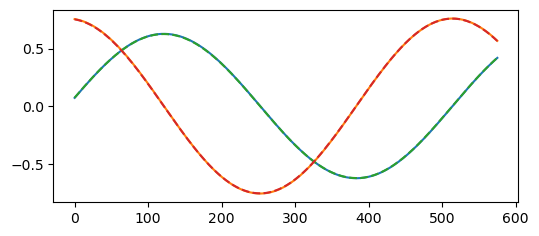

In [6]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break


In [7]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=0.046950, valid=0.038206, test=0.038389
	validation loss decreased (inf -> 0.038206), saving model ...
	epoch 2 losses: train=0.026586, valid=0.020814, test=0.020941
	validation loss decreased (0.038206 -> 0.020814), saving model ...
	epoch 3 losses: train=0.020422, valid=0.019671, test=0.019734
	validation loss decreased (0.020814 -> 0.019671), saving model ...
	epoch 4 losses: train=0.017608, valid=0.016073, test=0.016185
	validation loss decreased (0.019671 -> 0.016073), saving model ...
	epoch 5 losses: train=0.013561, valid=0.011440, test=0.011557
	validation loss decreased (0.016073 -> 0.011440), saving model ...
	epoch 6 losses: train=0.010860, valid=0.010724, test=0.010762
	validation loss decreased (0.011440 -> 0.010724), saving model ...
	epoch 7 losses: train=0.010293, valid=0.010820, test=0.010885
	early stopping counter: 1 out of 10
	epoch 8 losses: train=0.009655, valid=0.009478, test=0.009558
	validation loss de

In [8]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

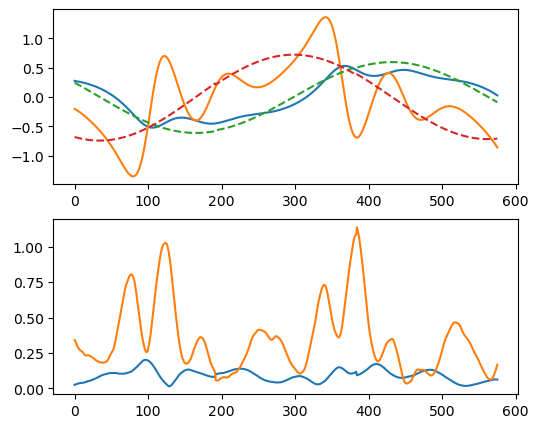

In [9]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[1]
        stat_u = model_output[2]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(stat_u[0, :, :2])

        plt.show()

        break


In [10]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=0.217526, valid=0.106206, test=0.106064
	validation loss decreased (inf -> 0.106206), saving model ...
	epoch 2 losses: train=0.095099, valid=0.084941, test=0.084760
	validation loss decreased (0.106206 -> 0.084941), saving model ...
	epoch 3 losses: train=0.061759, valid=0.043497, test=0.043788
	validation loss decreased (0.084941 -> 0.043497), saving model ...
	epoch 4 losses: train=0.037194, valid=0.026624, test=0.026725
	validation loss decreased (0.043497 -> 0.026624), saving model ...
	epoch 5 losses: train=0.019956, valid=0.013073, test=0.012974
	validation loss decreased (0.026624 -> 0.013073), saving model ...
	epoch 6 losses: train=0.010875, valid=0.007059, test=0.007001
	validation loss decreased (0.013073 -> 0.007059), saving model ...
	epoch 7 losses: train=0.005341, valid=0.004105, test=0.004090
	validation loss decreased (0.007059 -> 0.004105), saving model ...
	epoch 8 losses: train=0.003201, valid=0.002709, test=0.

In [11]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

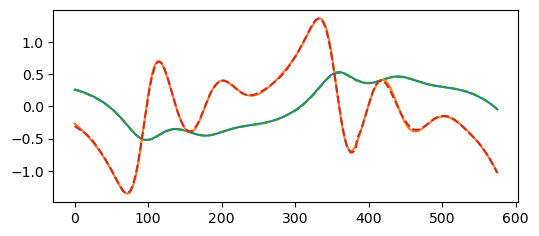

In [12]:
jdata = 0

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        stat = model_output[3]

        plt.figure(figsize=(6,2.5))
        plt.plot(truth[jdata, :, :2])
        plt.plot(stat[0, :, :2], linestyle='dashed')

        plt.show()

        break

In [17]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.041703, valid=0.022130, test=0.022119
	validation loss decreased (inf -> 0.022130), saving model ...
	epoch 2 losses: train=0.019607, valid=0.019362, test=0.019367
	validation loss decreased (0.022130 -> 0.019362), saving model ...
	epoch 3 losses: train=0.018487, valid=0.018297, test=0.018358
	validation loss decreased (0.019362 -> 0.018297), saving model ...
	epoch 4 losses: train=0.016662, valid=0.016663, test=0.016687
	validation loss decreased (0.018297 -> 0.016663), saving model ...
	epoch 5 losses: train=0.015873, valid=0.015900, test=0.015921
	validation loss decreased (0.016663 -> 0.015900), saving model ...
	epoch 6 losses: train=0.014742, valid=0.012754, test=0.012705
	validation loss decreased (0.015900 -> 0.012754), saving model ...
	epoch 7 losses: train=0.011499, valid=0.011095, test=0.011004
	validation loss decreased (0.012754 -> 0.011095), saving model ...
	epoch 8 losses: train=0.010581, valid=0.010375, 

In [18]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

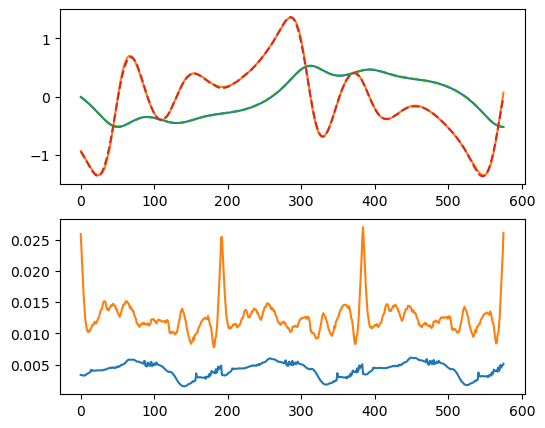

In [19]:
jdata = 3

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        exc = model_output[3]
        exc_u = model_output[4]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(exc[0, :, :2], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(exc_u[0, :, :2])

        plt.show()

        break

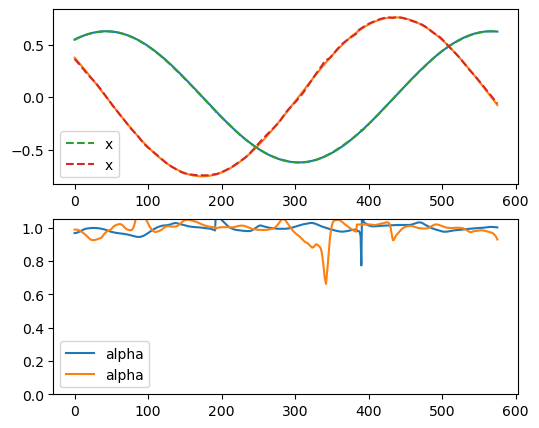

In [31]:
jdata = 10

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_output = model(back[[jdata]])
        pre = model_output[0]
        alpha = model_output[9]

        plt.figure(figsize=(6,5))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :2])
        plt.plot(pre[0, :, :2], linestyle='dashed', label='x')
        plt.legend()

        plt.subplot(2,1,2)
        plt.plot(alpha[0, :, :2], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break